In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import xarray as xr
from klepto.archives import file_archive
from diagnostics_pkg import operators_layered as ol
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import numpy.ma as ma
import qgutils as qg
import matplotlib as mpl
from skimage import measure
from scipy import interpolate

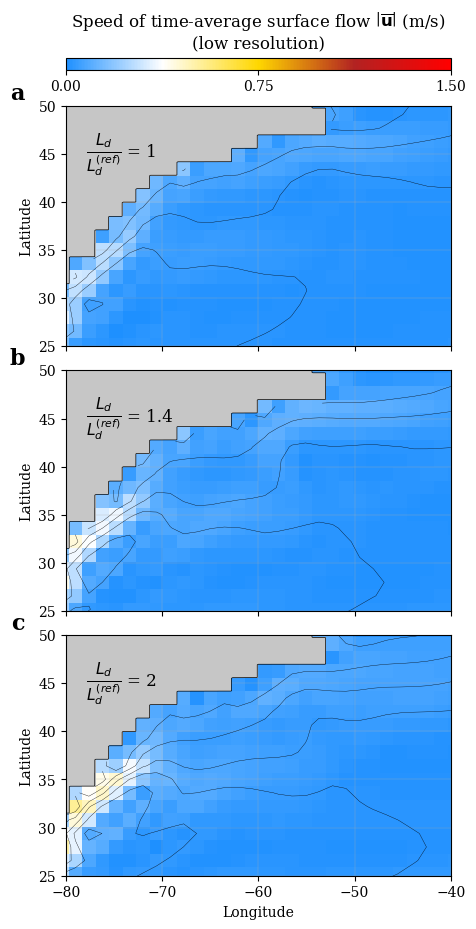

In [2]:
savepath = "data/"

lat_min = 25
lat_max = 50
lon_min = -80
lon_max = -40

drho_facs = [1, 2, 4]

plt.rcParams['font.family'] = 'serif'

fig = plt.figure(figsize=(5, 10))
grid = plt.GridSpec(3, 1, hspace=0.1, wspace=0)

cs = ["dodgerblue", "white", "gold", "firebrick", "red"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("cmap_name", cs)

Rd_labels = ["1", "1.4", "2"]
labels = ["a", "b", "c"]
R0 = 39066.430787677964

for i, drho_fac in enumerate(drho_facs):
        
    drho = np.array([ 2.13, 1.72, 1.41, 1.01, 0. ])[::-1]*drho_fac
    
    # open datasets
    
    axes = fig.add_subplot(grid[i])

    # topo mask 
    ds_topo = xr.open_dataset(savepath + "topo_lr.nc")
    topo = ds_topo["zb"][0,0,:,:]
    mask = topo < 0
    mx = ma.masked_array(np.zeros(np.shape(topo)), mask=mask)
    zeros = topo*0
        
    # mean vorticity
    
    ds_u = xr.open_dataset(savepath + "u_mean_64_" + str(drho_fac) + "drho.nc")
    ds_v = xr.open_dataset(savepath + "v_mean_64_" + str(drho_fac) + "drho.nc")
    
    lat_mod = ds_u["u.x"].y
    lon_mod = ds_u["u.x"].x
    speed_mean = np.sqrt(ds_u["u.x"].sel(level=4, drop=True)**2 + ds_v["u.y"].sel(level=4, drop=True)**2)
    
    # #  mean sea level
    
    N_interp = 500
    lon = np.linspace(lon_mod[0], lon_mod[-1], N_interp)
    lat = np.linspace(lat_mod[0], lat_mod[-1], N_interp)
    
    ds_level = xr.open_dataset(savepath + "isopycs_" + str(drho_fac) + "drho.nc")
    ssh = ds_level["h"][-1]
    ssh_interp = ssh.interp(x = lon, y = lat, method = "nearest")
    
    v = 2
    levels = np.linspace(-v, v, 21)
    
    # axes.contour(ssh_interp.x, ssh_interp.y, ssh_interp, vmin = -v, vmax = v, colors = 'k', levels = levels, linewidths = 0.55, linestyles = "-")
    axes.contour(ssh.x, ssh.y, ssh, vmin = -v, vmax = v, colors = 'k', levels = levels, linewidths = 0.25, linestyles = "-")   
    
    topo_interp = topo.interp(x = lon, y = lat, method = "nearest")
    
    # coastlines
    axes.pcolormesh(lon_mod, lat_mod, mx, cmap = "Grays", vmin = -1, vmax = 2, zorder = 2)
    axes.contour(lon, lat, topo_interp, levels = [0], colors = "k", linewidths = 0.5)

    v = 1.5
    levels = np.linspace(0, v, 21)
    
    # mean speed fields
    cplot = axes.pcolormesh(lon_mod, lat_mod, speed_mean, vmin = 0, vmax = v, cmap = cmap)
    #cplot = axes.contourf(lon_mod, lat_mod, speed_mean, vmin = 0, vmax = v, cmap = cmap, levels = levels)
    
    axes.set_ylabel("Latitude")

    if i == 0:
        #axes.set_title("time-average surface flow")
        # add text for axis label
        divider = make_axes_locatable(axes)
        cax = axes.inset_axes((0, 1.15,1, 0.05))
        
        cbar = plt.colorbar(cplot, cax=cax, orientation='horizontal', ticks = [0, v/2, v])
        cax.set_xlabel('Speed of time-average surface flow ' + r'$\left|\overline{\mathbf{u}}\right|$ (m/s)' + '\n(low resolution)', size = 12, rotation = 0)
        cax.xaxis.set_label_coords(0.5,5)
        #cax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
        
    if i == 2:
        axes.set_xlabel("Longitude")
    else:
        axes.set_xticklabels([])
    axes.set_ylabel("Latitude")

    axes.text(-0.125, 1.05, labels[i], weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)
    
    axes.set_xticks(np.linspace(-80, -40, 5))
        
    # set lateral and longitudinal extend
    axes.set_xlim([lon_min, lon_max])
    axes.set_ylim([lat_min, lat_max])
    axes.set_aspect(1)

    # add grid
    axes.grid(zorder = 1, linewidth = 0.2)
    
    # add text for deformation radius
    axes.text(0.1, 0.8, r'$\frac{L_d}{L_d^{(ref)}}$', horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)
    axes.text(0.16, 0.8075, '= ' + Rd_labels[i], verticalalignment='center', transform=axes.transAxes, size = 12)

plt.savefig('gulf_stream_low_res.png', dpi = 200, bbox_inches='tight', format = 'png')